In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200) # to see all output of spreadsheet

# Original Dataset
These datasets consist of basketball statistics from NBA, BAA, and ABA leagues. "Team Stats Per Game.csv" measures offensive skills and "Opponent Stats Per Game.csv" measures defensive skills. Both measure per-game averages for a team over a season.

## Labels from "Team Stats Per Game.csv"
season : year the season took place (Possible Values: 1947-2026) (Ex. 2026 refers to the current 2025-2026 season)\
lg : league/association (Possible Values: NBA, ABA, BAA)\
team : full team name (Possible Values: 97 unique team names) (1)(2)\
abbreviation : abbreviated version of team name\
playoffs : boolean value indicating whether the team made it to the post-season tournaments (3)(4)\
g : total games played by the team in the season (5)\
mp_per_game : minutes played per game (240 is usually the standard)\
fg_per_game : field goals made per game\
fga_per_game : field goal attempts per game\
fg_percent : field goal percentage (accuracy)\
x3p_per_game : 3-pointers made per game\
x3pa_per_game : 3-pointer attempts per game\
x3p_percent : 3-point shooting percentage (accuracy)\
x2p_per_game : 2-pointers made\
x2pa_per_game : 2-pointer attempts\
x2p_percent : 2-point shooting percentage (accuracy)\
ft_per_game : free throws made\
fta_per_game : free throw attempts\
ft_percent : free throw percentage (accuracy)\
orb_per_game : offensive rebounds\
drb_per_game : defensive rebounds\
trb_per_game : total rebounds\
ast_per_game : assists\
stl_per_game : steals\
blk_per_game : blocks\
tov_per_game : turnovers\
pf_per_game : personal fouls\
pts_per_game : total points scored per game

## Labels from "Opponent Stats Per Game.csv"
"Opponent Stats Per Game.csv" includes the same labels but with "opp_" added to the beginning to indicate opponent statistics. 

## Footnotes
(1) Since this dataset spans from 1947-2026, this includes all defunct teams, and teams who have since changed their names. There are currently only 30 active NBA teams.\
(2) This label also includes a value "Team League" for the average statistics for all teams for the entire season\
(3) This includes teams who made it to the Play-In Tournaments, which is why there are 20 teams marked as TRUE per season for this label, when the official playoffs are usually only 16 teams.\
(4) Since the 2026 season is ongoing, 'playoffs' is automatically marked FALSE for all teams\
(5) Usually each team plays 82 games, however there are outliers. (During COVID, many games were dropped. Also the NBA has had 'lockout" seasons where they ended early due to union disagreements). 



In [2]:
team_df = pd.read_csv('Team Stats Per Game.csv')
opp_df = pd.read_csv('Opponent Stats Per Game.csv')

# merging the datasets
common_columns = ['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp_per_game']
merged_df = pd.merge(team_df, opp_df, on=common_columns)

# add column for point differential
merged_df['point_diff'] = merged_df['pts_per_game'] - merged_df['opp_pts_per_game']

# save into new .csv file
merged_df.to_csv('Full_Basketball_Stats.csv', index=False)

In [3]:
merged_df.shape

(1907, 50)

In [4]:
merged_df.head()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,opp_fg_per_game,opp_fga_per_game,opp_fg_percent,opp_x3p_per_game,opp_x3pa_per_game,opp_x3p_percent,opp_x2p_per_game,opp_x2pa_per_game,opp_x2p_percent,opp_ft_per_game,opp_fta_per_game,opp_ft_percent,opp_orb_per_game,opp_drb_per_game,opp_trb_per_game,opp_ast_per_game,opp_stl_per_game,opp_blk_per_game,opp_tov_per_game,opp_pf_per_game,opp_pts_per_game,point_diff
0,2026,NBA,Atlanta Hawks,ATL,False,51.0,241.0,43.2,91.4,0.473,14.5,39.1,0.372,28.7,52.3,0.549,16.2,20.9,0.775,10.0,32.2,42.2,30.7,9.4,4.7,14.5,19.9,117.2,43.0,90.2,0.477,13.2,37.1,0.356,29.8,53.1,0.561,19.1,23.9,0.798,11.7,35.0,46.7,27.4,8.9,5.0,16.0,18.2,118.3,-1.1
1,2026,NBA,Boston Celtics,BOS,False,48.0,241.0,42.9,91.4,0.469,15.6,42.5,0.368,27.3,48.9,0.558,14.9,18.9,0.791,12.6,32.3,44.9,23.9,7.8,5.3,12.0,20.2,116.3,38.7,86.8,0.446,14.3,39.3,0.363,24.5,47.5,0.514,18.0,22.7,0.794,11.5,30.8,42.3,25.6,5.9,4.4,13.6,18.8,109.7,6.6
2,2026,NBA,Brooklyn Nets,BRK,False,47.0,241.6,37.8,85.1,0.444,14.0,40.6,0.345,23.7,44.5,0.534,18.1,23.2,0.782,10.9,29.3,40.2,25.3,7.6,4.4,15.2,20.0,107.7,42.1,85.7,0.491,12.6,33.0,0.382,29.4,52.7,0.559,17.6,22.4,0.786,10.2,32.8,43.0,27.5,8.5,4.8,13.8,19.9,114.4,-6.7
3,2026,NBA,Chicago Bulls,CHI,False,49.0,241.0,43.1,90.4,0.477,14.7,39.5,0.373,28.4,50.9,0.557,16.9,21.5,0.785,10.0,35.2,45.3,29.9,7.3,4.9,14.3,18.9,117.8,43.9,92.9,0.473,13.8,37.5,0.367,30.1,55.3,0.544,18.1,23.2,0.783,10.8,34.0,44.8,27.7,8.7,5.3,12.4,18.7,119.7,-1.9
4,2026,NBA,Charlotte Hornets,CHO,False,50.0,241.5,41.3,88.9,0.464,15.3,40.9,0.373,26.0,48.0,0.541,18.5,22.7,0.813,12.2,33.5,45.8,26.8,6.7,4.6,15.7,19.1,116.2,42.5,89.6,0.474,13.3,36.2,0.367,29.2,53.4,0.547,16.3,20.2,0.803,10.4,29.3,39.7,27.4,8.4,4.5,12.6,20.5,114.6,1.6


In [5]:
merged_df.tail()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,opp_fg_per_game,opp_fga_per_game,opp_fg_percent,opp_x3p_per_game,opp_x3pa_per_game,opp_x3p_percent,opp_x2p_per_game,opp_x2pa_per_game,opp_x2p_percent,opp_ft_per_game,opp_fta_per_game,opp_ft_percent,opp_orb_per_game,opp_drb_per_game,opp_trb_per_game,opp_ast_per_game,opp_stl_per_game,opp_blk_per_game,opp_tov_per_game,opp_pf_per_game,opp_pts_per_game,point_diff
1902,1947,BAA,Providence Steamrollers,PRO,False,60.0,NaN,27.2,93.0,0.292,NaN,NaN,NaN,27.2,93.0,0.292,18.2,27.8,0.655,NaN,NaN,NaN,8.0,NaN,NaN,NaN,20.3,72.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.2,-1.7
1903,1947,BAA,St. Louis Bombers,STB,True,61.0,NaN,26.2,96.3,0.272,NaN,NaN,NaN,26.2,96.3,0.272,14.1,23.0,0.616,NaN,NaN,NaN,4.8,NaN,NaN,NaN,20.2,66.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.1,2.5
1904,1947,BAA,Toronto Huskies,TRH,False,60.0,NaN,25.3,94.5,0.267,NaN,NaN,NaN,25.3,94.5,0.267,16.1,25.9,0.622,NaN,NaN,NaN,7.7,NaN,NaN,NaN,21.2,66.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.0,-4.4
1905,1947,BAA,Washington Capitols,WSC,True,60.0,NaN,28.7,96.6,0.297,NaN,NaN,NaN,28.7,96.6,0.297,16.4,23.2,0.706,NaN,NaN,NaN,6.3,NaN,NaN,NaN,19.1,73.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.9,9.9
1906,1947,BAA,League Average,NaN,False,60.0,NaN,25.9,92.9,0.279,NaN,NaN,NaN,25.9,92.9,0.279,15.9,24.8,0.641,NaN,NaN,NaN,6.9,NaN,NaN,NaN,20.8,67.8,25.9,92.9,0.279,NaN,NaN,NaN,25.9,92.9,0.279,15.9,24.8,0.641,NaN,NaN,NaN,6.9,NaN,NaN,NaN,20.8,67.8,0.0


In [6]:
merged_df.columns

Index(['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp_per_game',
       'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game',
       'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game',
       'x2p_percent', 'ft_per_game', 'fta_per_game', 'ft_percent',
       'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game',
       'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game',
       'pts_per_game', 'opp_fg_per_game', 'opp_fga_per_game', 'opp_fg_percent',
       'opp_x3p_per_game', 'opp_x3pa_per_game', 'opp_x3p_percent',
       'opp_x2p_per_game', 'opp_x2pa_per_game', 'opp_x2p_percent',
       'opp_ft_per_game', 'opp_fta_per_game', 'opp_ft_percent',
       'opp_orb_per_game', 'opp_drb_per_game', 'opp_trb_per_game',
       'opp_ast_per_game', 'opp_stl_per_game', 'opp_blk_per_game',
       'opp_tov_per_game', 'opp_pf_per_game', 'opp_pts_per_game',
       'point_diff'],
      dtype='str')

In [7]:
merged_df.dtypes

season                 int64
lg                       str
team                     str
abbreviation             str
playoffs                bool
g                    float64
mp_per_game          float64
fg_per_game          float64
fga_per_game         float64
fg_percent           float64
x3p_per_game         float64
x3pa_per_game        float64
x3p_percent          float64
x2p_per_game         float64
x2pa_per_game        float64
x2p_percent          float64
ft_per_game          float64
fta_per_game         float64
ft_percent           float64
orb_per_game         float64
drb_per_game         float64
trb_per_game         float64
ast_per_game         float64
stl_per_game         float64
blk_per_game         float64
tov_per_game         float64
pf_per_game          float64
pts_per_game         float64
opp_fg_per_game      float64
opp_fga_per_game     float64
opp_fg_percent       float64
opp_x3p_per_game     float64
opp_x3pa_per_game    float64
opp_x3p_percent      float64
opp_x2p_per_ga

In [8]:
merged_df.describe()

,season,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,opp_fg_per_game,opp_fga_per_game,opp_fg_percent,opp_x3p_per_game,opp_x3pa_per_game,opp_x3p_percent,opp_x2p_per_game,opp_x2pa_per_game,opp_x2p_percent,opp_ft_per_game,opp_fta_per_game,opp_ft_percent,opp_orb_per_game,opp_drb_per_game,opp_trb_per_game,opp_ast_per_game,opp_stl_per_game,opp_blk_per_game,opp_tov_per_game,opp_pf_per_game,opp_pts_per_game,point_diff
count,1907.000000,1906.000000,1717.000000,1906.000000,1906.000000,1905.000000,1464.000000,1464.000000,1464.000000,1906.000000,1906.000000,1906.000000,1906.000000,1906.000000,1905.000000,1577.000000,1577.000000,1854.000000,1906.000000,1521.000000,1520.000000,1647.000000,1906.000000,1906.000000,1669.000000,1667.000000,1666.000000,1464.000000,1464.000000,1464.000000,1669.000000,1667.000000,1667.000000,1669.000000,1668.000000,1667.000000,1544.000000,1544.000000,1663.000000,1667.0000,1519.000000,1519.000000,1647.000000,1669.000000,1906.000000,1906.000000
mean,1993.349240,79.028856,241.609552,39.541868,87.429801,0.452543,5.847268,16.582172,0.332948,35.052466,74.693389,0.474935,20.399948,27.169203,0.752578,12.664236,31.061129,46.122654,23.045016,8.122880,5.021382,16.020158,22.858604,103.974921,39.864769,86.399940,0.461250,5.847609,16.580874,0.336594,34.736369,71.837013,0.486687,19.753325,26.127398,0.756675,12.525389,30.972539,44.288755,23.3982,8.123239,5.021330,16.019854,22.442840,103.980063,-0.005142
std,20.982797,7.823157,0.830039,4.365137,7.253792,0.036527,4.097197,11.046917,0.046585,6.435393,15.916727,0.047799,3.449769,4.816927,0.032343,2.422075,2.433716,7.236571,3.239153,1.140759,0.938993,2.450845,2.771312,9.773447,3.639469,6.110245,0.022142,3.962841,10.718724,0.038551,6.164240,14.327374,0.032039,2.946438,4.042150,0.018110,2.075454,2.426316,4.207494,2.6666,1.004250,0.750594,2.494327,2.472031,9.789420,4.468265
min,1947.000000,11.000000,237.700000,22.400000,70.700000,0.246000,0.100000,0.900000,0.104000,22.400000,41.800000,0.246000,12.200000,16.600000,0.590000,7.600000,24.900000,35.600000,4.500000,1.900000,0.400000,1.300000,15.500000,60.100000,25.900000,68.800000,0.279000,0.300000,1.500000,0.115000,23.600000,45.700000,0.279000,13.300000,17.300000,0.641000,8.000000,24.500000,36.300000,6.9000,1.900000,0.400000,1.300000,16.200000,63.900000,-15.200000
25%,1976.500000,82.000000,241.000000,36.600000,82.000000,0.442000,2.300000,7.000000,0.318750,29.700000,61.800000,0.458000,17.800000,23.600000,0.734000,10.800000,29.300000,42.000000,21.200000,7.300000,4.400000,14.300000,20.700000,97.900000,37.100000,81.700000,0.449000,2.200000,6.900000,0.323000,29.700000,60.800000,0.467000,17.600000,23.100000,0.745000,10.900000,29.100000,41.700000,21.6000,7.400000,4.500000,14.200000,20.400000,98.025000,-2.900000
50%,1995.000000,82.000000,241.500000,40.000000,86.800000,0.458000,5.400000,15.300000,0.346000,32.300000,71.150000,0.480000,19.700000,26.300000,0.754000,12.400000,30.800000,43.900000,23.200000,8.000000,4.900000,15.400000,22.800000,104.900000,40.100000,86.200000,0.461000,5.500000,15.600000,0.349000,31.900000,66.800000,0.484000,19.300000,25.600000,0.757000,12.300000,30.800000,43.400000,23.5000,8.000000,5.000000,15.500000,22.300000,105.100000,0.000000
75%,2011.000000,82.000000,242.100000,42.800000,91.300000,0.474000,8.500000,23.400000,0.363000,41.600000,88.475000,0.500000,22.500000,30.000000,0.774000,14.200000,32.800000,46.675000,25.200000,8.800000,5.500000,17.500000,24.900000,111.075000,42.600000,90.200000,0.474000,8.000000,22.400000,0.362000,40.900000,85.400000,0.503000,21.500000,28.500000,0.769000,14.000000,32.800000,45.700000,25.3000,8.800000,5.500000,17.500000,24.300000,111.075000,3.100000
max,2026.000000,84.000000,244.900000,49.900000,119.600000,0.545000,17.800000,48.200000,0.428000,49.900000,119.600000,0.5970

In [9]:
unique_teams = sorted(merged_df['team'].unique())
print(f"There are {len(unique_teams)} unique team labels:\n")
for team in unique_teams:
    print(team)

There are 97 unique team labels:

Anaheim Amigos
Anderson Packers
Atlanta Hawks
Baltimore Bullets
Boston Celtics
Brooklyn Nets
Buffalo Braves
Capital Bullets
Carolina Cougars
Charlotte Bobcats
Charlotte Hornets
Chicago Bulls
Chicago Packers
Chicago Stags
Chicago Zephyrs
Cincinnati Royals
Cleveland Cavaliers
Cleveland Rebels
Dallas Chaparrals
Dallas Mavericks
Denver Nuggets
Denver Rockets
Detroit Falcons
Detroit Pistons
Fort Wayne Pistons
Golden State Warriors
Houston Mavericks
Houston Rockets
Indiana Pacers
Indianapolis Jets
Indianapolis Olympians
Kansas City Kings
Kansas City-Omaha Kings
Kentucky Colonels
League Average
Los Angeles Clippers
Los Angeles Lakers
Los Angeles Stars
Memphis Grizzlies
Memphis Pros
Memphis Sounds
Memphis Tams
Miami Floridians
Miami Heat
Milwaukee Bucks
Milwaukee Hawks
Minneapolis Lakers
Minnesota Muskies
Minnesota Pipers
Minnesota Timberwolves
New Jersey Americans
New Jersey Nets
New Orleans Buccaneers
New Orleans Hornets
New Orleans Jazz
New Orleans Pelicans

# Cleaning the Dataset
- only include NBA games
- remove "League Average" statistics, since this information is already in the dataset
- only include the years 1980 - present (Since many statistics like 3 pointers weren't introduced until the 1980s)
- check for duplicates
- check for NaN values
- deal with name changes for teams over the years

In [10]:
# only keep NBA games
NBA_merged_df = merged_df[merged_df['lg'] == 'NBA']

In [11]:
# remove League Average statistics
NBA_merged_df = NBA_merged_df[NBA_merged_df['team'] != 'League Average']

In [12]:
# only 1980 to present
NBA_merged_df = NBA_merged_df[NBA_merged_df['season'] >= 1980]

In [13]:
# check for duplicate rows
NBA_merged_df.loc[merged_df.duplicated()]

,season,lg,team,abbreviation,playoffs,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,opp_fg_per_game,opp_fga_per_game,opp_fg_percent,opp_x3p_per_game,opp_x3pa_per_game,opp_x3p_percent,opp_x2p_per_game,opp_x2pa_per_game,opp_x2p_percent,opp_ft_per_game,opp_fta_per_game,opp_ft_percent,opp_orb_per_game,opp_drb_per_game,opp_trb_per_game,opp_ast_per_game,opp_stl_per_game,opp_blk_per_game,opp_tov_per_game,opp_pf_per_game,opp_pts_per_game,point_diff


In [14]:
# check for null values
NBA_merged_df.isna().sum()

season               0
lg                   0
team                 0
abbreviation         0
playoffs             0
g                    0
mp_per_game          0
fg_per_game          0
fga_per_game         0
fg_percent           0
x3p_per_game         0
x3pa_per_game        0
x3p_percent          0
x2p_per_game         0
x2pa_per_game        0
x2p_percent          0
ft_per_game          0
fta_per_game         0
ft_percent           0
orb_per_game         0
drb_per_game         0
trb_per_game         0
ast_per_game         0
stl_per_game         0
blk_per_game         0
tov_per_game         0
pf_per_game          0
pts_per_game         0
opp_fg_per_game      0
opp_fga_per_game     0
opp_fg_percent       0
opp_x3p_per_game     0
opp_x3pa_per_game    0
opp_x3p_percent      0
opp_x2p_per_game     0
opp_x2pa_per_game    0
opp_x2p_percent      0
opp_ft_per_game      0
opp_fta_per_game     0
opp_ft_percent       0
opp_orb_per_game     0
opp_drb_per_game     0
opp_trb_per_game     0
opp_ast_per

In [15]:
unique_NBA_teams = sorted(NBA_merged_df['team'].unique())
print(f"There are {len(unique_NBA_teams)} unique NBA team labels:\n")
for team in unique_NBA_teams:
    print(team)

There are 39 unique NBA team labels:

Atlanta Hawks
Boston Celtics
Brooklyn Nets
Charlotte Bobcats
Charlotte Hornets
Chicago Bulls
Cleveland Cavaliers
Dallas Mavericks
Denver Nuggets
Detroit Pistons
Golden State Warriors
Houston Rockets
Indiana Pacers
Kansas City Kings
Los Angeles Clippers
Los Angeles Lakers
Memphis Grizzlies
Miami Heat
Milwaukee Bucks
Minnesota Timberwolves
New Jersey Nets
New Orleans Hornets
New Orleans Pelicans
New Orleans/Oklahoma City Hornets
New York Knicks
Oklahoma City Thunder
Orlando Magic
Philadelphia 76ers
Phoenix Suns
Portland Trail Blazers
Sacramento Kings
San Antonio Spurs
San Diego Clippers
Seattle SuperSonics
Toronto Raptors
Utah Jazz
Vancouver Grizzlies
Washington Bullets
Washington Wizards


In [16]:
# dealing with name changes
team_mapping = {
    'Seattle SuperSonics': 'Oklahoma City Thunder',
    'New Jersey Nets': 'Brooklyn Nets',
    'Vancouver Grizzlies': 'Memphis Grizzlies',
    'San Diego Clippers': 'Los Angeles Clippers',
    'New Orleans Hornets': 'New Orleans Pelicans',
    'New Orleans/Oklahoma City Hornets': 'New Orleans Pelicans',
    'Charlotte Bobcats': 'Charlotte Hornets',
    'Washington Bullets': 'Washington Wizards',
    'Kansas City Kings': 'Sacramento Kings'
}

NBA_merged_df['team'] = NBA_merged_df['team'].replace(team_mapping)

unique_NBA_teams = sorted(NBA_merged_df['team'].unique())
print(f"There are {len(unique_NBA_teams)} unique NBA team labels:\n")
for team in unique_NBA_teams:
    print(team)

There are 30 unique NBA team labels:

Atlanta Hawks
Boston Celtics
Brooklyn Nets
Charlotte Hornets
Chicago Bulls
Cleveland Cavaliers
Dallas Mavericks
Denver Nuggets
Detroit Pistons
Golden State Warriors
Houston Rockets
Indiana Pacers
Los Angeles Clippers
Los Angeles Lakers
Memphis Grizzlies
Miami Heat
Milwaukee Bucks
Minnesota Timberwolves
New Orleans Pelicans
New York Knicks
Oklahoma City Thunder
Orlando Magic
Philadelphia 76ers
Phoenix Suns
Portland Trail Blazers
Sacramento Kings
San Antonio Spurs
Toronto Raptors
Utah Jazz
Washington Wizards


In [17]:
# fix corresponding abbreviations
unique_NBA_abbr = sorted(NBA_merged_df['abbreviation'].unique())
print(f"There are {len(unique_NBA_abbr)} unique NBA abbreviation labels:\n")
for abbreviation in unique_NBA_abbr:
    print(abbreviation)

There are 40 unique NBA abbreviation labels:

ATL
BOS
BRK
CHA
CHH
CHI
CHO
CLE
DAL
DEN
DET
GSW
HOU
IND
KCK
LAC
LAL
MEM
MIA
MIL
MIN
NJN
NOH
NOK
NOP
NYK
OKC
ORL
PHI
PHO
POR
SAC
SAS
SDC
SEA
TOR
UTA
VAN
WAS
WSB


In [18]:
abbr_mapping = {
    'SEA': 'OKC', 
    'NJN': 'BRK', 
    'VAN': 'MEM', 
    'WSB': 'WAS', 
    'KCK': 'SAC', 
    'CHH': 'NOP',  
    'NOH': 'NOP',
    'NOK': 'NOP',
    'CHA': 'CHO',
    'SDC': 'LAC'
}

NBA_merged_df['abbreviation'] = NBA_merged_df['abbreviation'].replace(abbr_mapping)

In [19]:
# fixing the double abbreviations for the Charlotte Hornets (complicated history)
NBA_merged_df.loc[(NBA_merged_df['team'] == 'Charlotte Hornets') & (NBA_merged_df['abbreviation'] == 'NOP'), 'team'] = 'New Orleans Pelicans'
NBA_merged_df.loc[NBA_merged_df['team'] == 'Charlotte Hornets', 'abbreviation'] = 'CHO'

In [20]:
print(NBA_merged_df[['team', 'abbreviation']].drop_duplicates().sort_values('team'))

                      team abbreviation
0            Atlanta Hawks          ATL
1           Boston Celtics          BOS
2            Brooklyn Nets          BRK
4        Charlotte Hornets          CHO
3            Chicago Bulls          CHI
5      Cleveland Cavaliers          CLE
6         Dallas Mavericks          DAL
7           Denver Nuggets          DEN
8          Detroit Pistons          DET
9    Golden State Warriors          GSW
10         Houston Rockets          HOU
11          Indiana Pacers          IND
12    Los Angeles Clippers          LAC
13      Los Angeles Lakers          LAL
14       Memphis Grizzlies          MEM
15              Miami Heat          MIA
16         Milwaukee Bucks          MIL
17  Minnesota Timberwolves          MIN
18    New Orleans Pelicans          NOP
19         New York Knicks          NYK
20   Oklahoma City Thunder          OKC
21           Orlando Magic          ORL
22      Philadelphia 76ers          PHI
23            Phoenix Suns          PHO


In [21]:
# save the cleaned dataset
NBA_merged_df.to_csv('Cleaned_NBA_Stats.csv', index=False)

# Cleaned Dataset Attributes

In [22]:
NBA_merged_df.shape

(1314, 50)

In [23]:
NBA_merged_df.head()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,opp_fg_per_game,opp_fga_per_game,opp_fg_percent,opp_x3p_per_game,opp_x3pa_per_game,opp_x3p_percent,opp_x2p_per_game,opp_x2pa_per_game,opp_x2p_percent,opp_ft_per_game,opp_fta_per_game,opp_ft_percent,opp_orb_per_game,opp_drb_per_game,opp_trb_per_game,opp_ast_per_game,opp_stl_per_game,opp_blk_per_game,opp_tov_per_game,opp_pf_per_game,opp_pts_per_game,point_diff
0,2026,NBA,Atlanta Hawks,ATL,False,51.0,241.0,43.2,91.4,0.473,14.5,39.1,0.372,28.7,52.3,0.549,16.2,20.9,0.775,10.0,32.2,42.2,30.7,9.4,4.7,14.5,19.9,117.2,43.0,90.2,0.477,13.2,37.1,0.356,29.8,53.1,0.561,19.1,23.9,0.798,11.7,35.0,46.7,27.4,8.9,5.0,16.0,18.2,118.3,-1.1
1,2026,NBA,Boston Celtics,BOS,False,48.0,241.0,42.9,91.4,0.469,15.6,42.5,0.368,27.3,48.9,0.558,14.9,18.9,0.791,12.6,32.3,44.9,23.9,7.8,5.3,12.0,20.2,116.3,38.7,86.8,0.446,14.3,39.3,0.363,24.5,47.5,0.514,18.0,22.7,0.794,11.5,30.8,42.3,25.6,5.9,4.4,13.6,18.8,109.7,6.6
2,2026,NBA,Brooklyn Nets,BRK,False,47.0,241.6,37.8,85.1,0.444,14.0,40.6,0.345,23.7,44.5,0.534,18.1,23.2,0.782,10.9,29.3,40.2,25.3,7.6,4.4,15.2,20.0,107.7,42.1,85.7,0.491,12.6,33.0,0.382,29.4,52.7,0.559,17.6,22.4,0.786,10.2,32.8,43.0,27.5,8.5,4.8,13.8,19.9,114.4,-6.7
3,2026,NBA,Chicago Bulls,CHI,False,49.0,241.0,43.1,90.4,0.477,14.7,39.5,0.373,28.4,50.9,0.557,16.9,21.5,0.785,10.0,35.2,45.3,29.9,7.3,4.9,14.3,18.9,117.8,43.9,92.9,0.473,13.8,37.5,0.367,30.1,55.3,0.544,18.1,23.2,0.783,10.8,34.0,44.8,27.7,8.7,5.3,12.4,18.7,119.7,-1.9
4,2026,NBA,Charlotte Hornets,CHO,False,50.0,241.5,41.3,88.9,0.464,15.3,40.9,0.373,26.0,48.0,0.541,18.5,22.7,0.813,12.2,33.5,45.8,26.8,6.7,4.6,15.7,19.1,116.2,42.5,89.6,0.474,13.3,36.2,0.367,29.2,53.4,0.547,16.3,20.2,0.803,10.4,29.3,39.7,27.4,8.4,4.5,12.6,20.5,114.6,1.6


In [24]:
NBA_merged_df.tail()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,opp_fg_per_game,opp_fga_per_game,opp_fg_percent,opp_x3p_per_game,opp_x3pa_per_game,opp_x3p_percent,opp_x2p_per_game,opp_x2pa_per_game,opp_x2p_percent,opp_ft_per_game,opp_fta_per_game,opp_ft_percent,opp_orb_per_game,opp_drb_per_game,opp_trb_per_game,opp_ast_per_game,opp_stl_per_game,opp_blk_per_game,opp_tov_per_game,opp_pf_per_game,opp_pts_per_game,point_diff
1355,1980,NBA,San Antonio Spurs,SAS,True,82.0,240.9,47.0,94.4,0.498,0.6,2.5,0.252,46.4,91.9,0.505,24.7,30.8,0.801,14.1,30.7,44.7,28.4,9.4,4.1,19.4,25.6,119.4,48.8,97.5,0.500,1.1,3.5,0.306,47.7,94.0,0.507,21.1,27.8,0.758,15.2,30.1,45.4,30.9,10.1,5.6,18.5,26.7,119.7,-0.3
1356,1980,NBA,Los Angeles Clippers,LAC,False,82.0,240.9,43.0,91.4,0.470,2.2,6.6,0.326,40.8,84.8,0.482,19.5,26.4,0.736,15.8,28.1,43.9,20.6,8.1,3.5,17.6,23.1,107.6,45.8,91.6,0.500,0.5,2.3,0.230,45.2,89.3,0.507,19.7,25.4,0.773,14.9,30.3,45.2,24.5,9.3,5.0,17.0,23.0,111.7,-4.1
1357,1980,NBA,Oklahoma City Thunder,OKC,True,82.0,241.8,43.3,92.3,0.470,0.7,2.3,0.312,42.6,90.0,0.474,21.1,27.5,0.768,16.8,31.1,47.9,24.9,9.1,5.2,18.2,22.7,108.5,41.6,90.5,0.459,0.7,2.9,0.246,40.8,87.6,0.466,20.0,26.2,0.764,14.7,29.4,44.0,24.6,8.9,4.8,18.5,24.4,103.8,4.7
1358,1980,NBA,Utah Jazz,UTA,False,82.0,241.5,41.2,83.1,0.496,0.7,2.3,0.319,40.5,80.9,0.501,19.2,23.7,0.809,11.8,28.8,40.6,24.5,8.0,4.4,18.8,24.5,102.4,43.4,87.6,0.496,0.8,2.6,0.318,42.6,85.0,0.501,20.8,26.9,0.772,14.1,27.9,42.0,24.4,8.7,4.9,15.5,21.7,108.4,-6.0
1359,1980,NBA,Washington Wizards,WAS,True,82.0,242.4,43.6,95.1,0.458,0.9,2.9,0.307,42.7,92.2,0.463,18.9,25.0,0.758,16.3,33.2,49.5,26.8,6.5,5.4,16.8,23.1,107.0,44.1,94.8,0.465,0.7,2.6,0.262,43.4,92.2,0.471,20.7,26.6,0.777,14.6,32.6,47.2,25.9,9.0,6.3,14.9,23.2,109.5,-2.5


In [25]:
NBA_merged_df.columns

Index(['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp_per_game',
       'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game',
       'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game',
       'x2p_percent', 'ft_per_game', 'fta_per_game', 'ft_percent',
       'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game',
       'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game',
       'pts_per_game', 'opp_fg_per_game', 'opp_fga_per_game', 'opp_fg_percent',
       'opp_x3p_per_game', 'opp_x3pa_per_game', 'opp_x3p_percent',
       'opp_x2p_per_game', 'opp_x2pa_per_game', 'opp_x2p_percent',
       'opp_ft_per_game', 'opp_fta_per_game', 'opp_ft_percent',
       'opp_orb_per_game', 'opp_drb_per_game', 'opp_trb_per_game',
       'opp_ast_per_game', 'opp_stl_per_game', 'opp_blk_per_game',
       'opp_tov_per_game', 'opp_pf_per_game', 'opp_pts_per_game',
       'point_diff'],
      dtype='str')

In [26]:
NBA_merged_df.dtypes

season                 int64
lg                       str
team                     str
abbreviation             str
playoffs                bool
g                    float64
mp_per_game          float64
fg_per_game          float64
fga_per_game         float64
fg_percent           float64
x3p_per_game         float64
x3pa_per_game        float64
x3p_percent          float64
x2p_per_game         float64
x2pa_per_game        float64
x2p_percent          float64
ft_per_game          float64
fta_per_game         float64
ft_percent           float64
orb_per_game         float64
drb_per_game         float64
trb_per_game         float64
ast_per_game         float64
stl_per_game         float64
blk_per_game         float64
tov_per_game         float64
pf_per_game          float64
pts_per_game         float64
opp_fg_per_game      float64
opp_fga_per_game     float64
opp_fg_percent       float64
opp_x3p_per_game     float64
opp_x3pa_per_game    float64
opp_x3p_percent      float64
opp_x2p_per_ga

In [27]:
NBA_merged_df.describe()

,season,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,x2pa_per_game,x2p_percent,ft_per_game,fta_per_game,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,opp_fg_per_game,opp_fga_per_game,opp_fg_percent,opp_x3p_per_game,opp_x3pa_per_game,opp_x3p_percent,opp_x2p_per_game,opp_x2pa_per_game,opp_x2p_percent,opp_ft_per_game,opp_fta_per_game,opp_ft_percent,opp_orb_per_game,opp_drb_per_game,opp_trb_per_game,opp_ast_per_game,opp_stl_per_game,opp_blk_per_game,opp_tov_per_game,opp_pf_per_game,opp_pts_per_game,point_diff
count,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000
mean,2004.146119,79.675799,241.668721,39.188661,84.587443,0.462888,6.190791,17.491172,0.336748,33.000989,67.096575,0.493710,19.166362,25.299011,0.758296,12.130213,30.782116,42.910350,23.467808,8.011948,5.036301,15.310731,21.886149,103.735616,39.191400,84.587747,0.462799,6.190868,17.489726,0.339915,33.001218,67.096499,0.493406,19.167504,25.299087,0.758111,12.128995,30.782344,42.911111,23.469254,8.013775,5.035616,15.307991,21.884932,103.738052,-0.002435
std,13.260066,7.354679,0.840060,3.254140,4.710702,0.020697,4.057933,10.953465,0.045255,5.315196,11.441062,0.029554,2.523105,3.314510,0.030017,2.003863,2.372104,2.138349,2.697341,1.063950,0.924532,1.814299,2.416680,7.826890,3.381279,4.764267,0.020261,3.912371,10.602536,0.037510,5.302082,11.186907,0.028888,2.547887,3.414415,0.017879,1.797410,2.440033,2.272334,2.552617,0.927116,0.749091,1.890898,2.287670,7.865765,4.699213
min,1980.000000,46.000000,240.000000,30.800000,71.200000,0.401000,0.100000,0.900000,0.104000,23.100000,41.800000,0.421000,12.200000,16.600000,0.660000,7.600000,24.900000,35.600000,15.600000,5.500000,2.400000,11.100000,15.500000,81.900000,30.300000,68.800000,0.402000,0.300000,1.500000,0.115000,23.600000,45.700000,0.414000,13.300000,17.300000,0.694000,8.000000,24.500000,36.300000,16.300000,5.600000,3.000000,11.300000,16.200000,83.400000,-15.200000
25%,1993.000000,82.000000,241.200000,36.600000,81.100000,0.448000,3.000000,9.100000,0.326000,29.300000,58.800000,0.473250,17.325000,22.900000,0.740000,10.600000,29.100000,41.400000,21.400000,7.200000,4.400000,14.000000,20.100000,97.500000,36.600000,80.900000,0.450000,3.000000,9.025000,0.332000,29.300000,59.300000,0.474000,17.300000,22.700000,0.746000,10.700000,28.900000,41.300000,21.600000,7.400000,4.500000,14.000000,20.200000,97.600000,-3.200000
50%,2005.000000,82.000000,241.500000,39.000000,84.600000,0.462000,5.800000,16.150000,0.349000,31.200000,64.800000,0.490000,18.850000,25.000000,0.759000,11.900000,30.500000,42.900000,23.400000,7.900000,4.900000,15.000000,21.700000,103.400000,39.200000,84.700000,0.462000,5.700000,16.200000,0.350000,31.000000,64.300000,0.490000,18.850000,24.950000,0.758000,11.900000,30.500000,42.800000,23.500000,7.900000,5.000000,15.050000,21.700000,103.800000,0.300000
75%,2016.000000,82.000000,242.100000,41.800000,88.100000,0.476000,8.875000,24.775000,0.365000,36.875000,75.675000,0.511000,20.700000,27.600000,0.779000,13.500000,32.400000,44.400000,25.400000,8.700000,5.600000,16.300000,23.500000,109.975000,41.700000,88.200000,0.475000,8.475000,23.400000,0.363000,36.800000,76.475000,0.509000,20.800000,27.600000,0.770000,13.500000,32.600000,44.400000,25.375000,8.600000,5.500000,16.300000,23.400000,109.500000,3.400000
max,2026.000000,82.000000,244.900000,48.500000,108.100000,0.545000,17.800000,48.200000,0.428000,48.200000

# Feature Analysis

In [28]:
# split the data between 3 eras
# 1980s to 2000s
era_80_00 = NBA_merged_df[(NBA_merged_df['season'] >= 1980) & (NBA_merged_df['season'] < 2000)]

# 2000s to 2020s
era_00_20 = NBA_merged_df[(NBA_merged_df['season'] >= 2000) & (NBA_merged_df['season'] < 2020)]

# 2020s to present
era_20_26 = NBA_merged_df[NBA_merged_df['season'] >= 2020]

print(f"1980-2000 rows: {len(era_80_00)}")
print(f"2000-2020 rows: {len(era_00_20)}")
print(f"2020-2026 rows: {len(era_20_26)}")

1980-2000 rows: 509
2000-2020 rows: 595
2020-2026 rows: 210


## Target Variable Distribution (point_diff)
Throughout all eras, the distribution of point_diff is Normal.

### 1980s to 2000s

In [29]:
skew_value = era_80_00['point_diff'].skew()
print(f"Skewness of Point Differential: {skew_value}")

Skewness of Point Differential: -0.24592701919475762


Text(0, 0.5, 'Count')

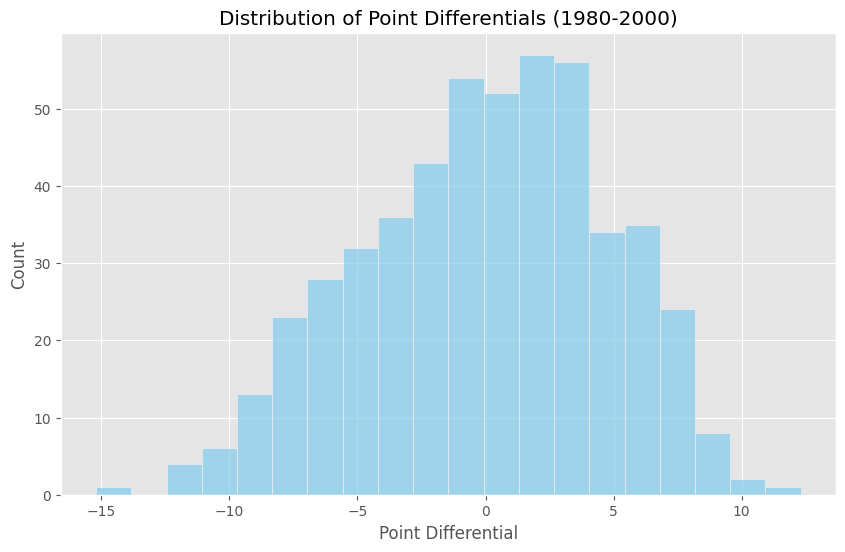

In [30]:
# show the target variable distribution for the dataset
plt.figure(figsize=(10, 6))
sns.histplot(data=era_80_00, x='point_diff', bins=20, color='skyblue')
plt.title('Distribution of Point Differentials (1980-2000)')
plt.xlabel('Point Differential')
plt.ylabel('Count')

### 2000s to 2020s

In [31]:
skew_value = era_00_20['point_diff'].skew()
print(f"Skewness of Point Differential: {skew_value}")

Skewness of Point Differential: -0.17799662886853812


Text(0, 0.5, 'Count')

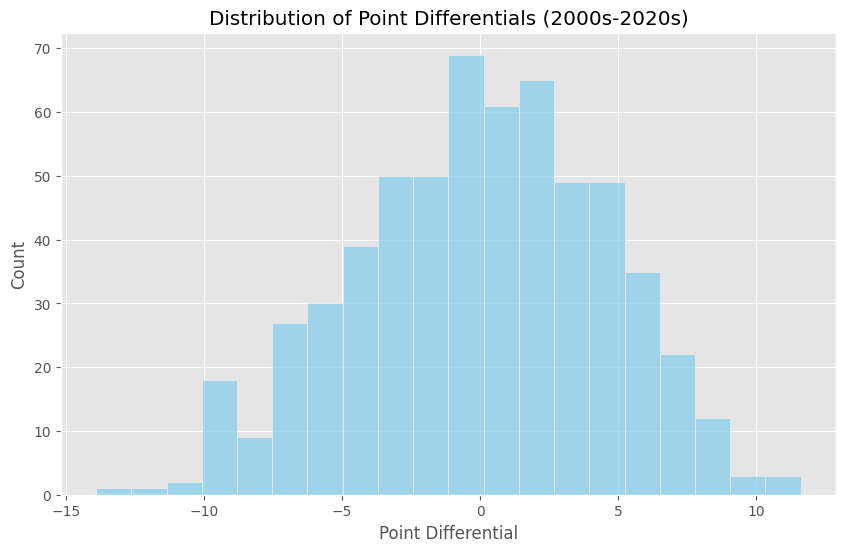

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(data=era_00_20, x='point_diff', bins=20, color='skyblue')
plt.title('Distribution of Point Differentials (2000s-2020s)')
plt.xlabel('Point Differential')
plt.ylabel('Count')

### 2020s to Present

In [33]:
# calculate skew
skew_value = era_20_26['point_diff'].skew()
print(f"Skewness of Point Differential: {skew_value}")

Skewness of Point Differential: -0.2948112254532661


Text(0, 0.5, 'Count')

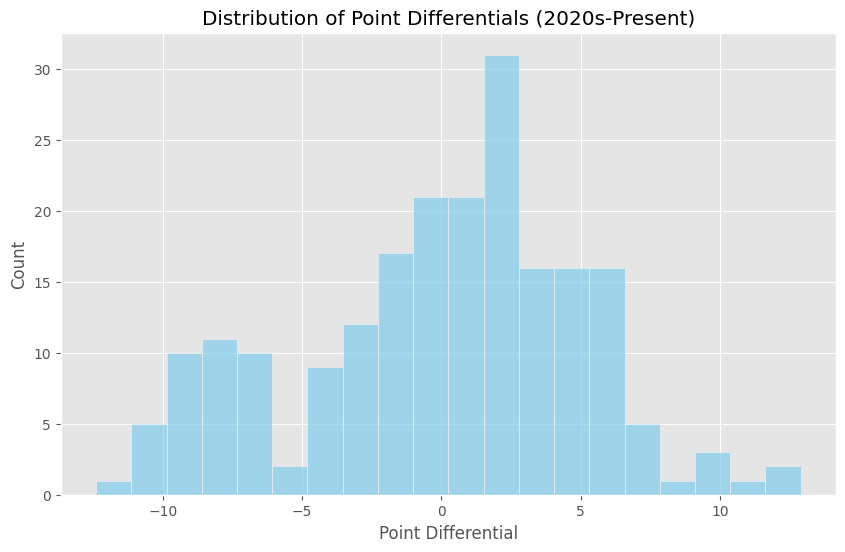

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(data=era_20_26, x='point_diff', bins=20, color='skyblue')
plt.title('Distribution of Point Differentials (2020s-Present)')
plt.xlabel('Point Differential')
plt.ylabel('Count')

## Correlation Matrix
For 1980-2000, these features are the strongest predictors of point_diff: fg_percent, x2p_percent, opp_x2p_percent, opp_drb_per_game\
For 2000-2020: fg_percent, opp_fg_percent\
For 2020-Present: x3p_percent, pts_per_game, fg_percent, x2p_percent, fg_per_game, opp_blk_per_game, opp_fg_per_game, opp_pts_per_game, opp_x2p_percent, opp_fg_percent

This shows the shift in strategy over the years. In the modern era, teams have shifted towards focusing on 3-pointers, whereas in the past field goals were the focus. This presents a potential conflict when splitting the dataset temporally. 

There are more features that are stronger predictors (above 0.5 or below -0.5) for the 2020s-Present era than any other era. This is most likely because this era has a more uniform strategy (since it is a smaller subset of the overall data), thus more predictable. The other eras (1980-2000 and 2000-2020) have less strong predictors since they encompass larger timelines, and thus more strategy shifts over the period. 

For feature selection, it is important we select features that are unique to each other to prevent multicollinearity. We can use this heatmap to prevent choosing redundant features. 

### 1980s to 2000s

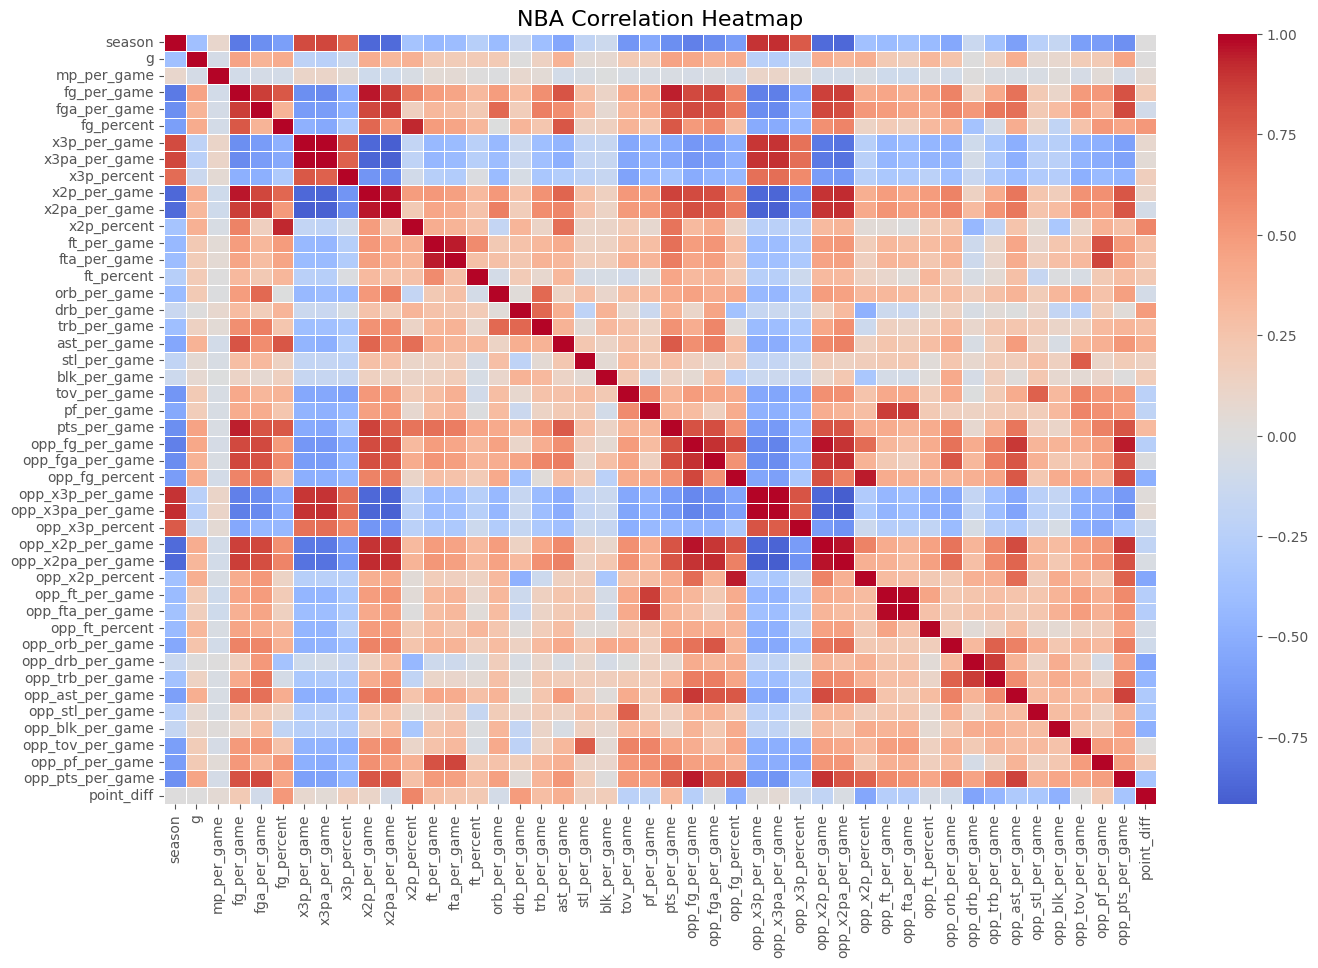

In [35]:
numeric_df = era_80_00.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('NBA Correlation Heatmap', fontsize=16)
plt.show()

In [36]:
target_corr = corr_matrix['point_diff'].sort_values(ascending=False)
print("Numerical Correlation")
print(target_corr)

Numerical Correlation
point_diff           1.000000
x2p_percent          0.583982
fg_percent           0.504240
drb_per_game         0.490436
ast_per_game         0.381363
pts_per_game         0.316675
trb_per_game         0.288878
ft_per_game          0.276760
fta_per_game         0.241674
ft_percent           0.219172
opp_pf_per_game      0.210063
fg_per_game          0.206486
blk_per_game         0.180116
x3p_percent          0.163626
stl_per_game         0.143019
x2p_per_game         0.109124
x3p_per_game         0.081054
opp_x3pa_per_game    0.054520
mp_per_game          0.050614
x3pa_per_game        0.043788
opp_x3p_per_game     0.019759
opp_tov_per_game     0.011808
season              -0.000079
g                   -0.000147
opp_fga_per_game    -0.012515
opp_x2pa_per_game   -0.036284
opp_ft_percent      -0.057436
x2pa_per_game       -0.073279
orb_per_game        -0.078153
fga_per_game        -0.088459
opp_orb_per_game    -0.093809
opp_x3p_percent     -0.114322
opp_x2p_per_game  

### 2000s to 2020s

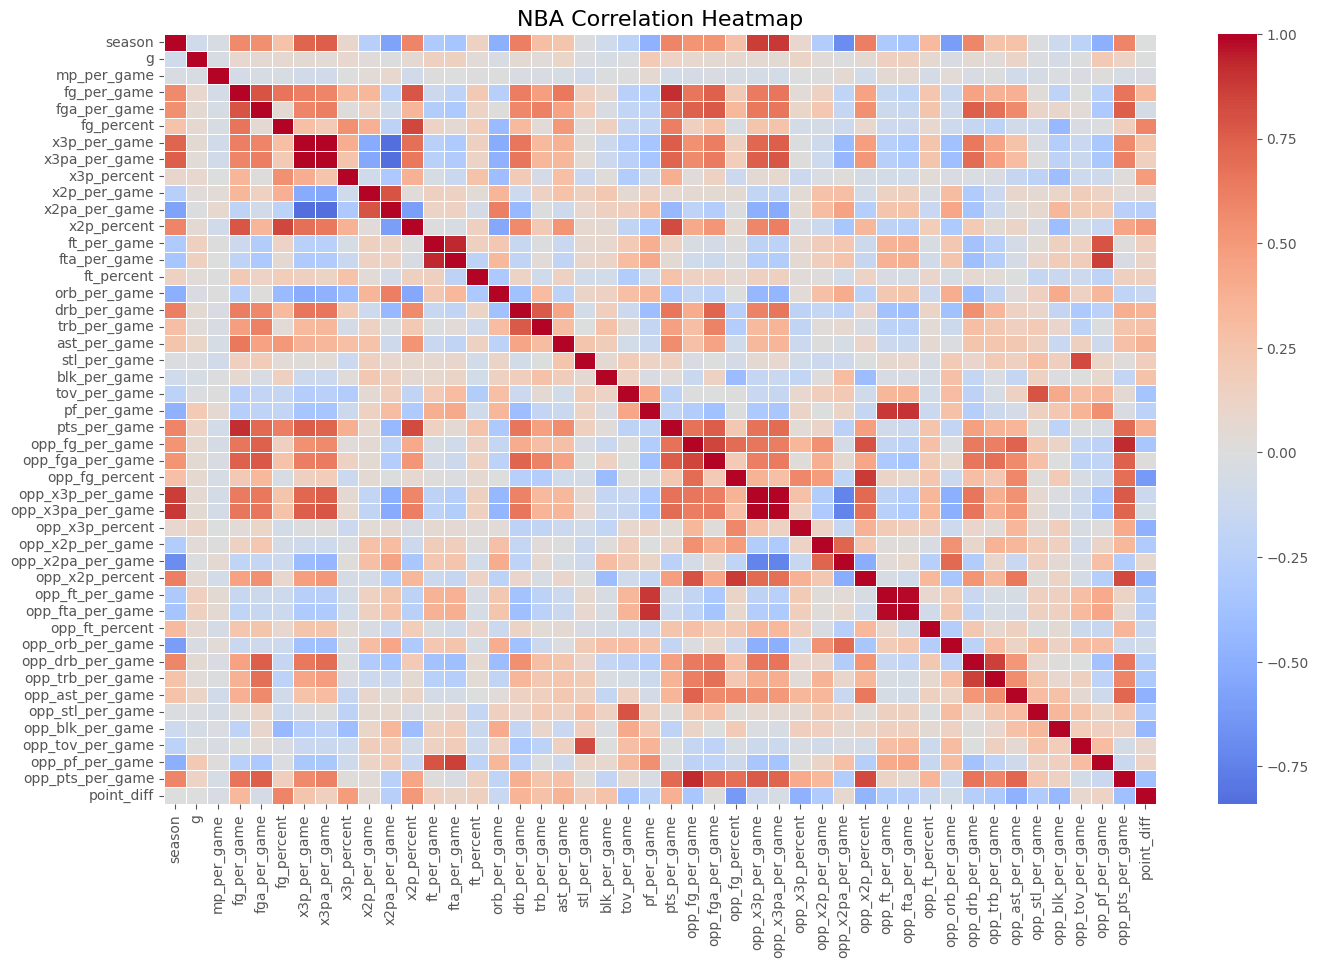

In [37]:
numeric_df = era_00_20.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('NBA Correlation Heatmap', fontsize=16)
plt.show()

In [38]:
target_corr = corr_matrix['point_diff'].sort_values(ascending=False)
print("Numerical Correlation")
print(target_corr)

Numerical Correlation
point_diff           1.000000
fg_percent           0.596786
x2p_percent          0.497298
x3p_percent          0.484668
pts_per_game         0.379708
ast_per_game         0.367398
drb_per_game         0.360208
fg_per_game          0.323828
trb_per_game         0.267787
blk_per_game         0.266110
x3p_per_game         0.238980
stl_per_game         0.170950
ft_per_game          0.166248
x3pa_per_game        0.166004
ft_percent           0.151605
opp_pf_per_game      0.127759
fta_per_game         0.114560
opp_tov_per_game     0.082389
opp_x2pa_per_game    0.075256
x2p_per_game         0.064312
opp_fga_per_game     0.010079
g                   -0.000319
season              -0.000368
mp_per_game         -0.033703
opp_x3pa_per_game   -0.051679
fga_per_game        -0.059933
opp_orb_per_game    -0.080124
opp_x3p_per_game    -0.121688
opp_ft_percent      -0.135799
orb_per_game        -0.148772
pf_per_game         -0.215895
x2pa_per_game       -0.254044
opp_fta_per_game  

### 2020s to Present

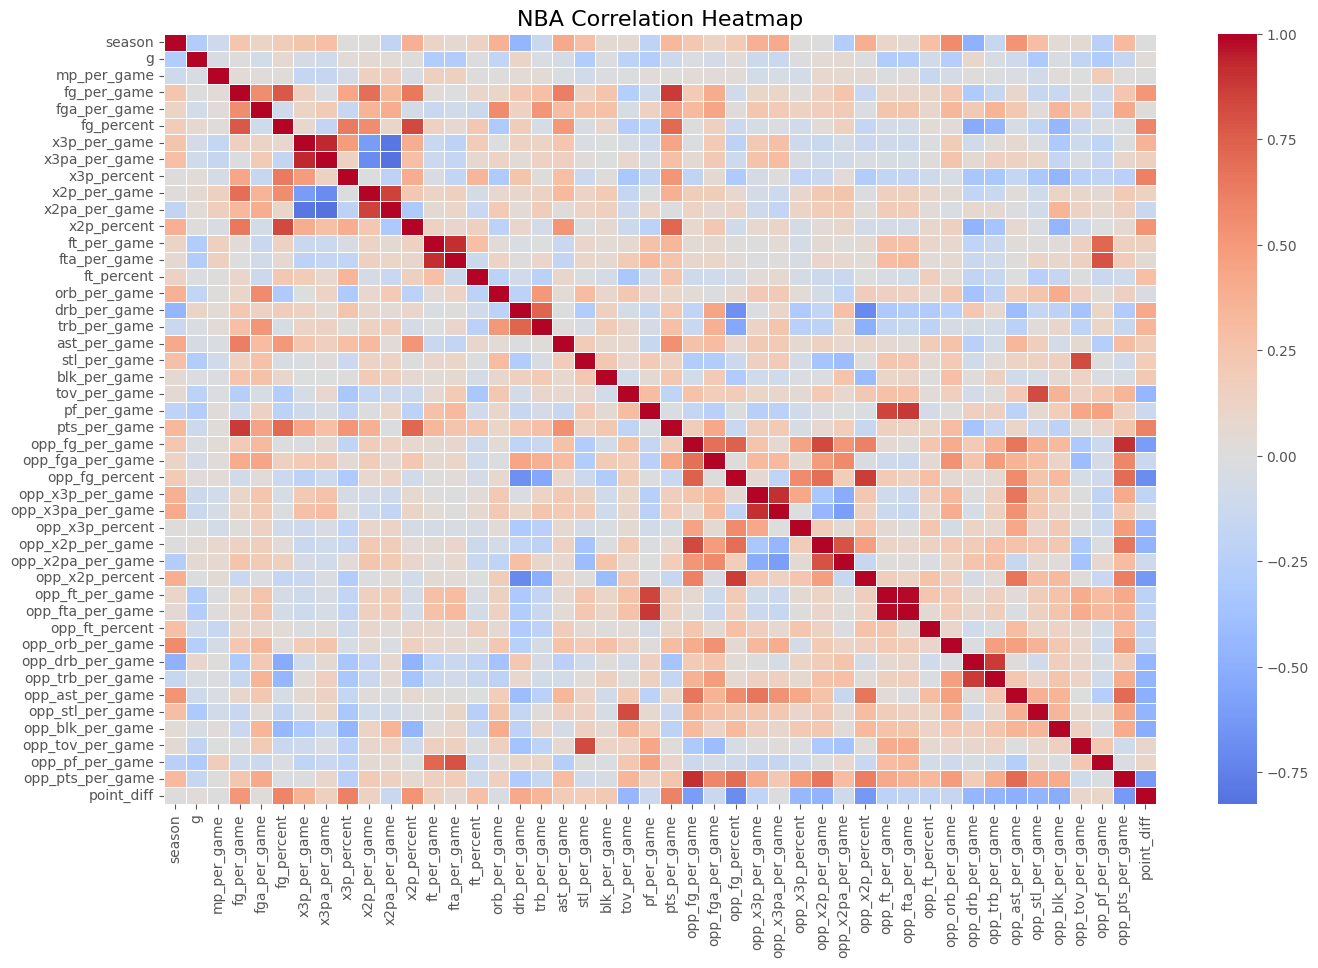

In [39]:
numeric_df = era_20_26.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('NBA Correlation Heatmap', fontsize=16)
plt.show()

In [40]:
target_corr = corr_matrix['point_diff'].sort_values(ascending=False)
print("Numerical Correlation")
print(target_corr)

Numerical Correlation
point_diff           1.000000
x3p_percent          0.610842
pts_per_game         0.605294
fg_percent           0.598664
x2p_percent          0.527541
fg_per_game          0.513746
drb_per_game         0.422145
x3p_per_game         0.363971
trb_per_game         0.350246
ft_percent           0.282657
blk_per_game         0.214317
ast_per_game         0.191851
stl_per_game         0.183599
x3pa_per_game        0.156711
ft_per_game          0.150555
x2p_per_game         0.144565
opp_pf_per_game      0.104331
opp_tov_per_game     0.093016
fta_per_game         0.047501
g                    0.028693
fga_per_game         0.020277
season               0.007203
mp_per_game          0.007045
opp_x3pa_per_game   -0.018367
orb_per_game        -0.035122
opp_x2pa_per_game   -0.100974
pf_per_game         -0.131344
x2pa_per_game       -0.134638
opp_fga_per_game    -0.137478
opp_orb_per_game    -0.158540
opp_ft_percent      -0.190315
opp_fta_per_game    -0.194644
opp_x3p_per_game  

## Skew for All Features
Depending on the ML model we choose, we may have to transform certain features (those with a skew >1 or <-1)

### 1980s to 2000s

In [41]:
skewness_series = era_80_00.select_dtypes(include=['number']).skew().sort_values(ascending=False)

print("Features Skews:")
print(skewness_series)

Features Skews:
x3p_per_game         0.776285
x3pa_per_game        0.718736
mp_per_game          0.648560
opp_x3p_per_game     0.627787
opp_drb_per_game     0.592876
blk_per_game         0.562271
opp_x3pa_per_game    0.547060
opp_tov_per_game     0.464105
tov_per_game         0.430109
opp_trb_per_game     0.344334
stl_per_game         0.333028
opp_blk_per_game     0.330580
ft_per_game          0.302321
opp_pf_per_game      0.265885
opp_stl_per_game     0.222134
fta_per_game         0.199018
opp_orb_per_game     0.160217
opp_ft_per_game      0.088906
opp_fta_per_game     0.059925
pf_per_game          0.037282
orb_per_game         0.034046
fga_per_game        -0.084639
drb_per_game        -0.092938
trb_per_game        -0.094991
season              -0.124458
opp_ast_per_game    -0.173072
ft_percent          -0.191317
pts_per_game        -0.208938
point_diff          -0.245927
opp_fga_per_game    -0.254861
x2p_percent         -0.258975
ast_per_game        -0.267233
fg_percent          -0.2

### 2000s to 2020s

In [42]:
skewness_series = era_00_20.select_dtypes(include=['number']).skew().sort_values(ascending=False)

print("Features Skews:")
print(skewness_series)

Features Skews:
opp_x3pa_per_game    0.957647
opp_x3p_per_game     0.917611
x3pa_per_game        0.772977
x3p_per_game         0.692974
mp_per_game          0.673711
ast_per_game         0.657080
drb_per_game         0.580610
x2p_percent          0.553122
pts_per_game         0.491953
fg_per_game          0.391041
opp_drb_per_game     0.381993
fga_per_game         0.340869
opp_fga_per_game     0.337961
opp_ft_per_game      0.333932
opp_pts_per_game     0.314331
trb_per_game         0.308665
pf_per_game          0.291488
stl_per_game         0.280529
blk_per_game         0.277379
opp_fta_per_game     0.270058
opp_tov_per_game     0.246682
opp_pf_per_game      0.230870
tov_per_game         0.229649
opp_orb_per_game     0.227914
ft_per_game          0.220473
fg_percent           0.193666
opp_stl_per_game     0.192227
fta_per_game         0.177855
opp_x2p_per_game     0.173335
opp_x2p_percent      0.155937
orb_per_game         0.152810
opp_trb_per_game     0.149419
opp_ft_percent       0.1

### 2020s to Present

In [43]:
skewness_series = era_20_26.select_dtypes(include=['number']).skew().sort_values(ascending=False)

print("Features Skews:")
print(skewness_series)

Features Skews:
orb_per_game         0.747769
stl_per_game         0.676834
drb_per_game         0.655232
mp_per_game          0.633319
x3p_per_game         0.456405
opp_tov_per_game     0.436015
x3pa_per_game        0.431437
opp_stl_per_game     0.388504
trb_per_game         0.367223
ft_per_game          0.356668
opp_blk_per_game     0.323828
ast_per_game         0.294972
opp_x3p_percent      0.281818
opp_pf_per_game      0.277020
opp_x3p_per_game     0.256313
fta_per_game         0.229927
blk_per_game         0.218448
opp_orb_per_game     0.207946
opp_pts_per_game     0.203073
opp_ast_per_game     0.201106
opp_trb_per_game     0.152743
opp_x3pa_per_game    0.133550
x3p_percent          0.070636
opp_fta_per_game     0.048761
opp_fg_per_game      0.011276
opp_drb_per_game     0.006269
season               0.000000
opp_ft_per_game     -0.005165
x2p_per_game        -0.039370
opp_fga_per_game    -0.042800
tov_per_game        -0.061420
opp_x2p_per_game    -0.064143
ft_percent          -0.0

## Outliers
Which features we choose will impact how we deal with outliers. If we choose a feature with few outliers, we may keep the outliers since they are insignificant. But if there are more outliers then we may transform or Winsorize the data.

### 1980s to 2000s

In [44]:
numeric_cols = era_80_00.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

minim = Q1 - 1.5 * IQR
maxim = Q3 + 1.5 * IQR

outliers = (numeric_cols < minim) | (numeric_cols > maxim)

outlier_counts = outliers.sum().sort_values(ascending=False)
print("Features with the most outliers:")
print(outlier_counts[outlier_counts > 0])

Features with the most outliers:
g                   29
opp_pts_per_game    11
opp_orb_per_game    10
mp_per_game          9
opp_stl_per_game     8
fg_percent           8
ft_percent           7
opp_fg_percent       7
x2p_percent          7
opp_trb_per_game     6
opp_x2p_percent      6
orb_per_game         5
opp_fta_per_game     5
ft_per_game          5
opp_x3p_percent      5
fga_per_game         5
opp_ft_per_game      5
opp_ast_per_game     4
blk_per_game         4
tov_per_game         4
trb_per_game         4
stl_per_game         4
opp_ft_percent       3
opp_fg_per_game      3
opp_blk_per_game     3
opp_drb_per_game     3
x3p_percent          3
opp_pf_per_game      3
ast_per_game         2
opp_fga_per_game     2
drb_per_game         2
fta_per_game         2
opp_tov_per_game     2
fg_per_game          2
pts_per_game         2
point_diff           1
pf_per_game          1
x3pa_per_game        1
x3p_per_game         1
dtype: int64


### 2000s to 2020s

In [45]:
numeric_cols = era_00_20.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

minim = Q1 - 1.5 * IQR
maxim = Q3 + 1.5 * IQR

outliers = (numeric_cols < minim) | (numeric_cols > maxim)

outlier_counts = outliers.sum().sort_values(ascending=False)
print("Features with the most outliers:")
print(outlier_counts[outlier_counts > 0])

Features with the most outliers:
g                    32
opp_x3p_per_game     16
tov_per_game         16
opp_stl_per_game     15
x2p_per_game         15
opp_x3pa_per_game    15
x2p_percent          14
fg_per_game          11
fg_percent           11
pts_per_game          9
x2pa_per_game         8
ft_percent            8
mp_per_game           8
x3p_percent           8
x3pa_per_game         8
ast_per_game          7
opp_pf_per_game       7
opp_trb_per_game      7
opp_fga_per_game      7
blk_per_game          7
trb_per_game          6
ft_per_game           6
orb_per_game          5
fta_per_game          5
opp_orb_per_game      5
opp_pts_per_game      5
opp_x3p_percent       5
opp_x2p_per_game      5
x3p_per_game          5
pf_per_game           5
fga_per_game          4
opp_ft_per_game       4
opp_tov_per_game      3
opp_ft_percent        3
opp_fg_per_game       3
opp_drb_per_game      3
stl_per_game          3
opp_fg_percent        2
opp_x2pa_per_game     2
opp_x2p_percent       2
drb_per

### 2020s to Present

In [46]:
numeric_cols = era_20_26.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

minim = Q1 - 1.5 * IQR
maxim = Q3 + 1.5 * IQR

outliers = (numeric_cols < minim) | (numeric_cols > maxim)

outlier_counts = outliers.sum().sort_values(ascending=False)
print("Features with the most outliers:")
print(outlier_counts[outlier_counts > 0])

Features with the most outliers:
g                    30
opp_fg_percent        6
stl_per_game          5
orb_per_game          5
opp_x2p_per_game      4
trb_per_game          4
opp_drb_per_game      4
pf_per_game           3
fg_percent            3
opp_x3p_percent       3
opp_stl_per_game      3
point_diff            3
opp_ft_per_game       2
opp_x2p_percent       2
opp_fg_per_game       2
ft_per_game           1
fta_per_game          1
opp_orb_per_game      1
opp_ft_percent        1
opp_fta_per_game      1
opp_x2pa_per_game     1
mp_per_game           1
opp_ast_per_game      1
opp_x3p_per_game      1
fg_per_game           1
opp_fga_per_game      1
opp_pts_per_game      1
x3p_percent           1
opp_tov_per_game      1
blk_per_game          1
x2p_percent           1
drb_per_game          1
x3p_per_game          1
ft_percent            1
x3pa_per_game         1
dtype: int64
